# Adapted from this [notebook](/home/links/ct715/eddy_feedback/reproduce/saffin_2024/saffin.ipynb)

In [2]:
import xarray as xr 
import matplotlib.pyplot as plt
import numpy as np
import os

import functions.eddy_feedback as ef 
import functions.data_wrangling as dw

In [3]:
path = '/home/links/ct715/data_storage/reanalysis/jra55_daily/processed_efp'
data_6h = os.path.join(path, '6h_ubar_epf-pr-QG_1MS_1958-2016.nc')
data_daily = os.path.join(path, 'daily_ubar_epf-pr-QG_1MS_1958-2016.nc')

# import dataset for maths servers
ds_6h = xr.open_dataset(data_6h)
ds_6h


<xarray.Dataset> Size: 38MB
Dimensions:  (time: 708, level: 37, lat: 73)
Coordinates:
  * lat      (lat) float64 584B -90.0 -87.5 -85.0 -82.5 ... 82.5 85.0 87.5 90.0
  * level    (level) float64 296B 1e+03 975.0 950.0 925.0 ... 5.0 3.0 2.0 1.0
  * time     (time) datetime64[ns] 6kB 1958-01-01 1958-02-01 ... 2016-12-01
Data variables:
    ubar     (time, level, lat) float32 8MB ...
    div1_pr  (time, level, lat) float64 15MB ...
    div1_QG  (time, level, lat) float64 15MB ...

In [4]:
djf = dw.seasonal_mean(ds_6h, season='djf')
jas = dw.seasonal_mean(ds_6h, season='jas')

Cutting incomplete seasons from dataset...
Cutting incomplete seasons from dataset...


### Zonal-mean zonal wind (DJF)

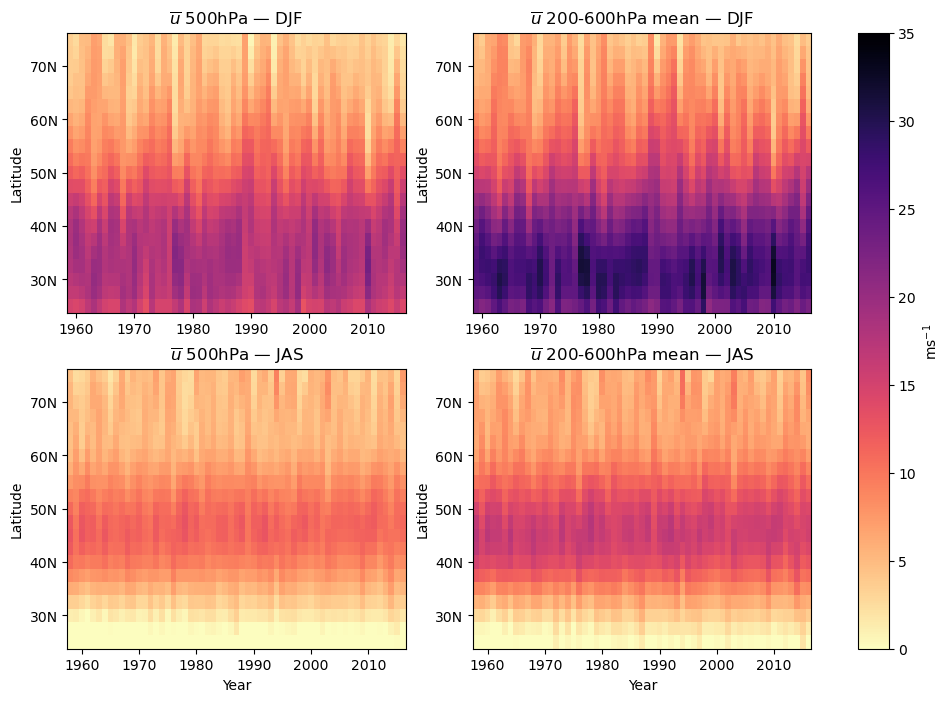

In [18]:
seasons = {'DJF': djf, 'JAS': jas}
level_params = {
    '500hPa':          lambda ds: ds.ubar.sel(level=500.),
    '200-600hPa mean': lambda ds: ds.ubar.sel(level=slice(600., 200.)).mean('level'),
}

vmin, vmax = 0, 35

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    for col, (level_name, level_fn) in enumerate(level_params.items()):
        ax = axes[row, col]

        u = level_fn(ds)
        u = u.where(ds.lat >= 25., drop=True)
        u = u.where(ds.lat <= 75., drop=True)
        u = u.transpose()

        im = u.plot(ax=ax, cmap='magma_r', vmin=vmin, vmax=vmax,
                    add_colorbar=False)
        ax.set_yticks(np.arange(30, 80, 10))
        ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
        ax.set_title(f'$\\overline{{u}}$ {level_name} — {season_name}')
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Year')

for ax in axes[0,:]:
    ax.set_xlabel('')

fig.colorbar(im, ax=axes, label='ms$^{-1}$')
plt.show()

### DivFy (primitive)

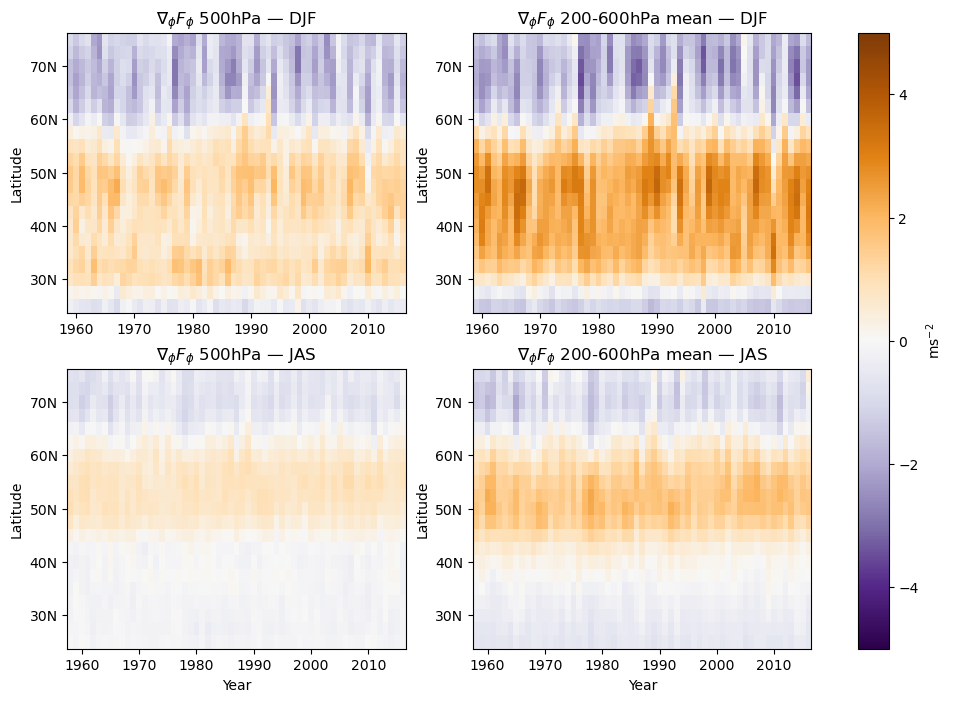

In [22]:
seasons = {'DJF': djf, 'JAS': jas}
level_params = {
    '500hPa':          lambda ds: ds.div1_pr.sel(level=500.),
    '200-600hPa mean': lambda ds: ds.div1_pr.sel(level=slice(600., 200.)).mean('level'),
}

vmin, vmax = -5,5

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    for col, (level_name, level_fn) in enumerate(level_params.items()):
        ax = axes[row, col]

        div1 = level_fn(ds)
        div1 = div1.where(ds.lat >= 25., drop=True)
        div1 = div1.where(ds.lat <= 75., drop=True)
        div1 = div1.transpose()

        im = div1.plot(ax=ax, cmap='PuOr_r', vmin=vmin, vmax=vmax,
                       add_colorbar=False)
        ax.set_yticks(np.arange(30, 80, 10))
        ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
        ax.set_title(f'$\\nabla_\\phi F_\\phi$ {level_name} — {season_name}')
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Year')

for ax in axes[0, :]:
    ax.set_xlabel('')

fig.colorbar(im, ax=axes, label='ms$^{-2}$')
plt.show()

### DivFy (QG)

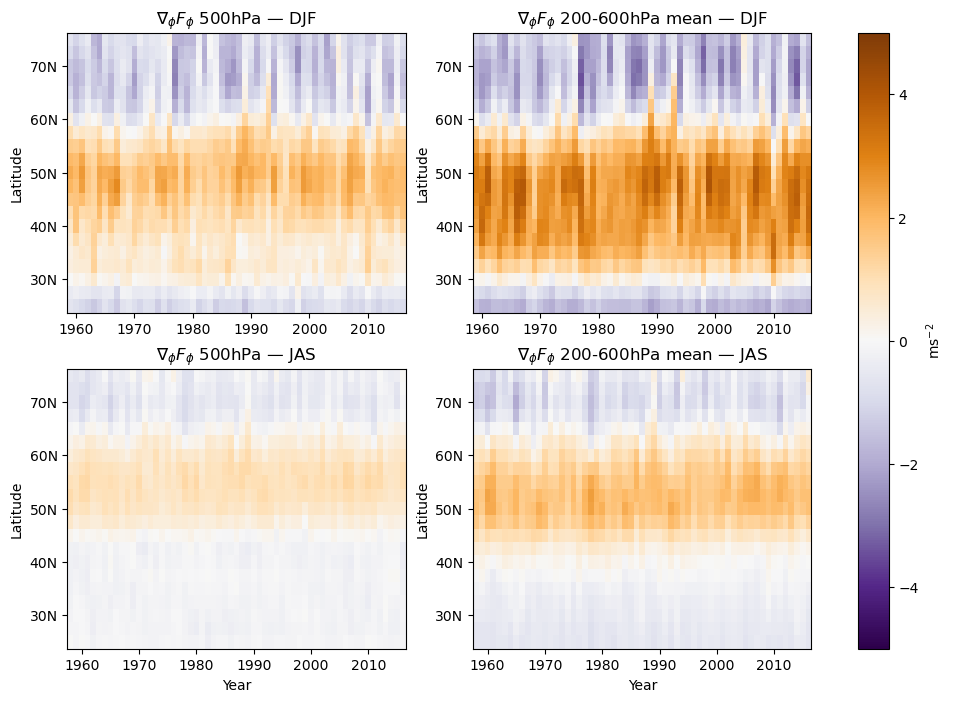

In [23]:
seasons = {'DJF': djf, 'JAS': jas}
level_params = {
    '500hPa':          lambda ds: ds.div1_QG.sel(level=500.),
    '200-600hPa mean': lambda ds: ds.div1_QG.sel(level=slice(600., 200.)).mean('level'),
}

vmin, vmax = -5,5

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    for col, (level_name, level_fn) in enumerate(level_params.items()):
        ax = axes[row, col]

        div1 = level_fn(ds)
        div1 = div1.where(ds.lat >= 25., drop=True)
        div1 = div1.where(ds.lat <= 75., drop=True)
        div1 = div1.transpose()

        im = div1.plot(ax=ax, cmap='PuOr_r', vmin=vmin, vmax=vmax,
                       add_colorbar=False)
        ax.set_yticks(np.arange(30, 80, 10))
        ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
        ax.set_title(f'$\\nabla_\\phi F_\\phi$ {level_name} — {season_name}')
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Year')

for ax in axes[0, :]:
    ax.set_xlabel('')

fig.colorbar(im, ax=axes, label='ms$^{-2}$')
plt.show()

# Covariance

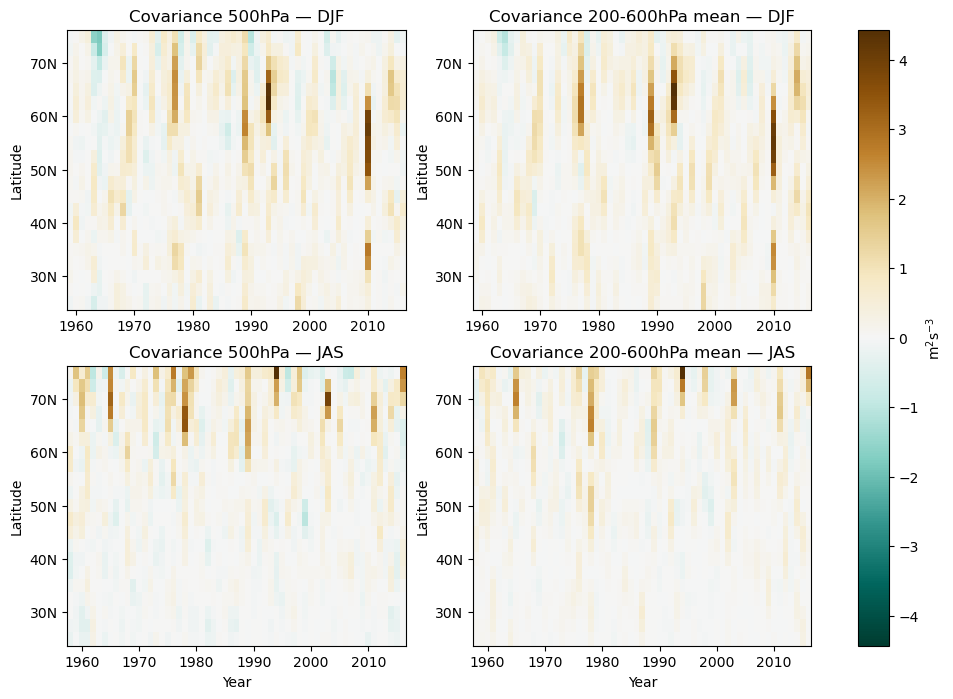

In [24]:
seasons = {'DJF': djf, 'JAS': jas}
level_params = {
    '500hPa':          lambda ds: (ds.ubar.sel(level=500.),
                                   ds.div1_pr.sel(level=500.)),
    '200-600hPa mean': lambda ds: (ds.ubar.sel(level=slice(600., 200.)).mean('level'),
                                   ds.div1_pr.sel(level=slice(600., 200.)).mean('level')),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    for col, (level_name, level_fn) in enumerate(level_params.items()):
        ax = axes[row, col]

        u, div1 = level_fn(ds)
        u     = u.where(ds.lat >= 25., drop=True).where(ds.lat <= 75., drop=True)
        div1  = div1.where(ds.lat >= 25., drop=True).where(ds.lat <= 75., drop=True)

        uanom    = u - u.mean('time')
        div1anom = div1 - div1.mean('time')
        prod = (uanom * div1anom).transpose()

        im = prod.plot(ax=ax, cmap='BrBG_r', add_colorbar=False)
        ax.set_yticks(np.arange(30, 80, 10))
        ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
        ax.set_title(f'Covariance {level_name} — {season_name}')
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Year')

for ax in axes[0, :]:
    ax.set_xlabel('')

fig.colorbar(im, ax=axes, label='m$^2$s$^{-3}$')
plt.show()

# Correlation

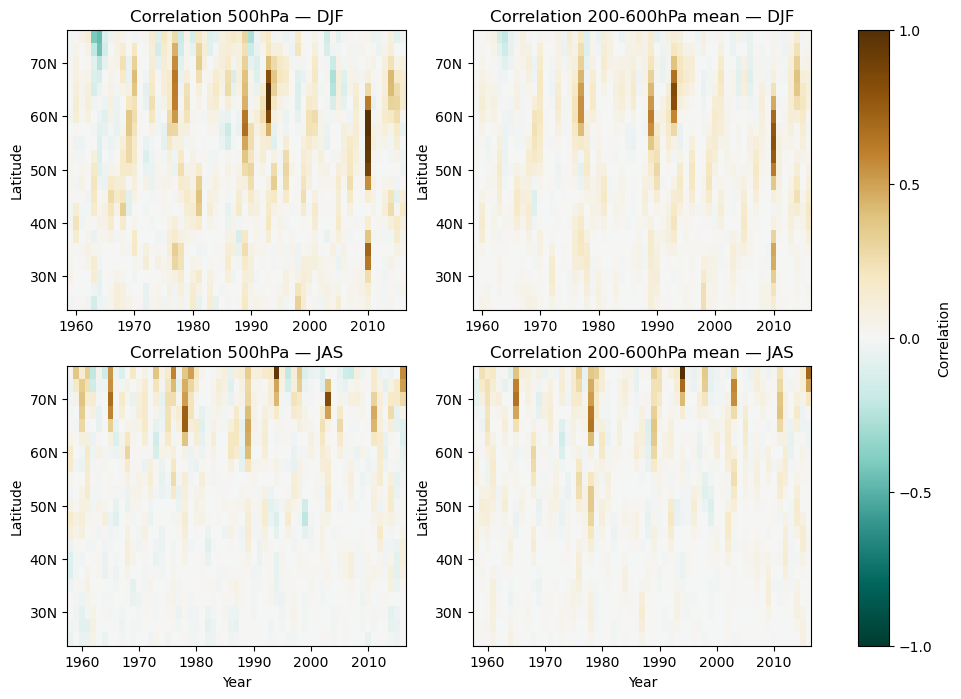

In [28]:
seasons = {'DJF': djf, 'JAS': jas}
level_params = {
    '500hPa':          lambda ds: (ds.ubar.sel(level=500.),
                                   ds.div1_pr.sel(level=500.)),
    '200-600hPa mean': lambda ds: (ds.ubar.sel(level=slice(600., 200.)).mean('level'),
                                   ds.div1_pr.sel(level=slice(600., 200.)).mean('level')),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    for col, (level_name, level_fn) in enumerate(level_params.items()):
        ax = axes[row, col]

        u, div1 = level_fn(ds)
        u    = u.where(ds.lat >= 25., drop=True).where(ds.lat <= 75., drop=True)
        div1 = div1.where(ds.lat >= 25., drop=True).where(ds.lat <= 75., drop=True)

        uanom    = u - u.mean('time')
        div1anom = div1 - div1.mean('time')
        prod = uanom * div1anom

        corr = prod / (u.std() * div1.std())
        # corr = corr.where(corr < 1).fillna(1)
        corr = corr.transpose()

        im = corr.plot(ax=ax, cmap='BrBG_r', vmin=-1., vmax=1.,
                       add_colorbar=False)
        ax.set_yticks(np.arange(30, 80, 10))
        ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
        ax.set_title(f'Correlation {level_name} — {season_name}')
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Year')

for ax in axes[0, :]:
    ax.set_xlabel('')

fig.colorbar(im, ax=axes, label='Correlation', ticks=[-1, -0.5, 0, 0.5, 1])
plt.show()
